# <span style="color:#00bfff">Unidad 4. Inteligencia Artificial Moderna</span>

## <span style="color:#00bfff">Redes Neuronales Artificiales RNA (ANN)</span>

Ejemplo de ANN con Keras sobre el dataset Iris. 

La red usa activación **ReLU** (`max(0, x)`) en las capas ocultas: es simple de calcular y evita (en gran medida) el problema del gradiente que desaparece que sí afecta a otras activaciones como sigmoid en redes profundas. La capa de salida usa **softmax**, que convierte los valores de salida en una distribución de probabilidad sobre las 3 clases de Iris (todas suman 1), ideal para clasificación multiclase junto con la función de pérdida `categorical_crossentropy`.

1. Instalación de la librería Tensorflow

In [ ]:
%pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report
import numpy as np

# 1. Cargar datos
iris = load_iris()
X, y = iris.data, iris.target.reshape(-1, 1)
# 2. Escalamiento de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. One-hot encoding para etiquetas
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# 4. División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42
)

# 5. Construcción del modelo ANN
model = Sequential(
    [
        Input(shape=(X.shape[1],)),  # 4 características de entrada
        Dense(10, activation="relu"),
        Dense(8, activation="relu"),  # Capa oculta con 8 neuronas
        Dense(3, activation="softmax"),  # 3 clases
    ]
)

# 6. Compilar modelo
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 7. Entrenar modelo
history = model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=1)

# 8. Evaluar modelo
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nPrecisión en test: {acc:.3f}")

# 9. Predicciones y reporte
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(
    "\nReporte de clasificación:\n",
    classification_report(y_true_labels, y_pred_labels, target_names=iris.target_names),
)

Visualización del entrenamiento

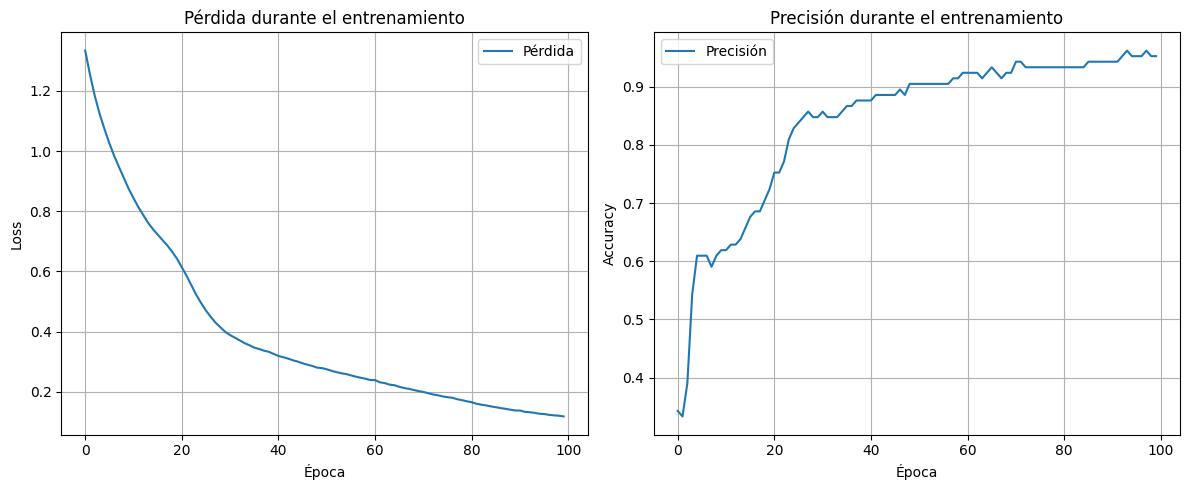

In [5]:
import matplotlib.pyplot as plt

# Visualizar evolución de la pérdida
plt.figure(figsize=(12, 5))

# Gráfico de la pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Pérdida")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Gráfico de la precisión
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Precisión")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## <span style="color:#00bfff">Redes Neuronales Convolucionales - CNN</span>

A continuación, se construye y entrena una Red Neuronal Convolucional (CNN) con Keras usando el clásico dataset MNIST, que contiene imágenes en escala de grises de dígitos escritos a mano (0 al 9) en tamaño 28x28 píxeles.

> Este notebook asume que ya se entienden los conceptos de convolución, kernels y canales vistos en [`computer-vision.ipynb`](computer-vision.ipynb) de esta misma unidad. En resumen: una capa `Conv2D` desliza un conjunto de kernels (filtros) sobre la imagen para detectar patrones locales (bordes, texturas, formas), y `MaxPooling2D` reduce la resolución espacial quedándose con el valor más fuerte de cada región, haciendo la red más eficiente y algo más tolerante a pequeños desplazamientos de la imagen.

1. Importación de librerías y carga de datos

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# Cargar dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizar a [0,1] y expandir dimensiones (para CNN)
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0 
X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Codificar las etiquetas (one-hot)
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10) 

2. Previsualización de datos cargados

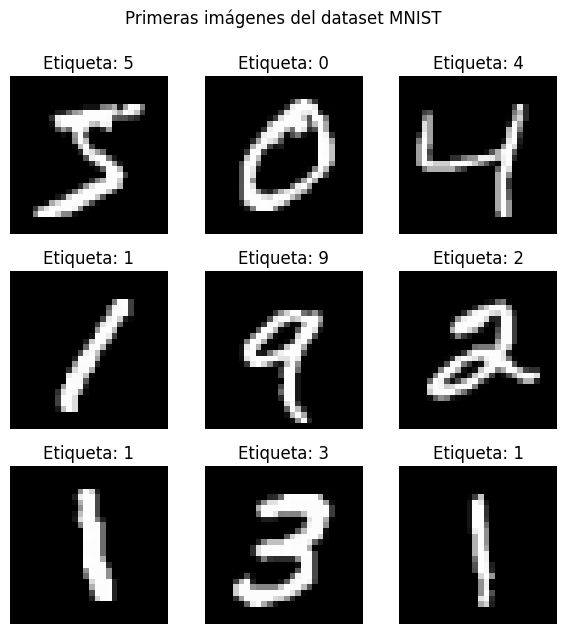

In [7]:
import matplotlib.pyplot as plt

# Mostrar las primeras 9 imágenes del conjunto de entrenamiento
plt.figure(figsize=(6, 6))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Primeras imágenes del dataset MNIST", y=1.05)
plt.show()

3. Construir el modelo CNN

In [ ]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(), # Se aplana la salida de la última capa convolucional para conectarla a la capa densa
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

4. Compilar y entrenar

In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train_cat, validation_split=0.1, epochs=5, batch_size=64) 

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9510 - loss: 0.1634 - val_accuracy: 0.9842 - val_loss: 0.0532
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9846 - loss: 0.0491 - val_accuracy: 0.9883 - val_loss: 0.0367
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9889 - loss: 0.0346 - val_accuracy: 0.9893 - val_loss: 0.0334
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9918 - loss: 0.0248 - val_accuracy: 0.9880 - val_loss: 0.0422
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9936 - loss: 0.0194 - val_accuracy: 0.9897 - val_loss: 0.0347


5. Evaluar y mostrar resultados

In [10]:
# Evaluación en test
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"\nPrecisión en test: {acc:.4f}") 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9899 - loss: 0.0319

Precisión en test: 0.9899


6. Visualizar curvas de entrenamiento

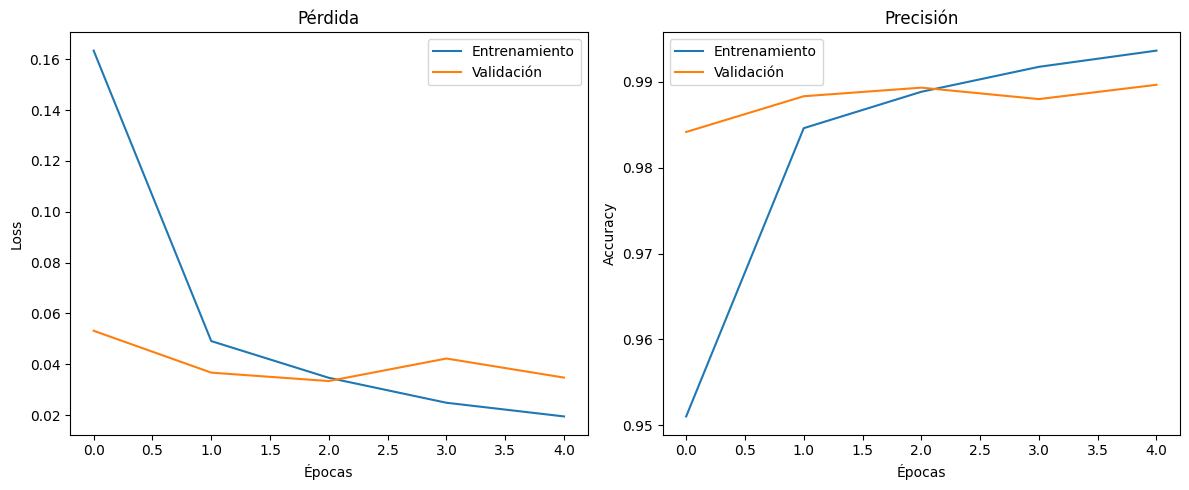

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Pérdida
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Precisión
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## <span style="color:#00bfff">Redes Neuronales Recurrentes - RNN</span>

Las RNN están diseñadas para datos secuenciales (series de tiempo, texto, audio): a diferencia de una red densa o convolucional, mantienen un "estado oculto" que se actualiza en cada paso, permitiendo que la salida en el paso $t$ dependa de lo visto en los pasos anteriores.

Usaremos específicamente **LSTM** (*Long Short-Term Memory*) en vez de una RNN simple. La razón es el problema del **gradiente que desaparece** (*vanishing gradient*): en una RNN simple, al propagar el error hacia atrás a través de muchos pasos de tiempo, el gradiente se va haciendo cada vez más pequeño, y la red termina "olvidando" dependencias de largo plazo. LSTM introduce un conjunto de "puertas" (de entrada, de olvido y de salida) que regulan explícitamente qué información se conserva o se descarta en cada paso, permitiendo así recordar patrones a más largo plazo.

1. Preparación de los datos

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Generar serie senoidal
x = np.linspace(0, 100, 500)
serie = np.sin(x)

# Escalar entre 0 y 1
scaler = MinMaxScaler()
serie_norm = scaler.fit_transform(serie.reshape(-1, 1))

# Crear ventanas de entrada/salida
def crear_ventanas(data, pasos=10):
    X, y = [], []
    for i in range(len(data) - pasos):
        X.append(data[i:i+pasos])
        y.append(data[i+pasos])
    return np.array(X), np.array(y)

pasos = 20
X, y = crear_ventanas(serie_norm, pasos)
X = X.reshape((X.shape[0], X.shape[1], 1))  # Requerido por LSTM

2. Construir y entrenar el modelo LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model = Sequential([
    Input(shape=(pasos, 1)),
    LSTM(50, activation='tanh'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=20, batch_size=16, verbose=1)

3. Evaluar y visualizar resultados

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


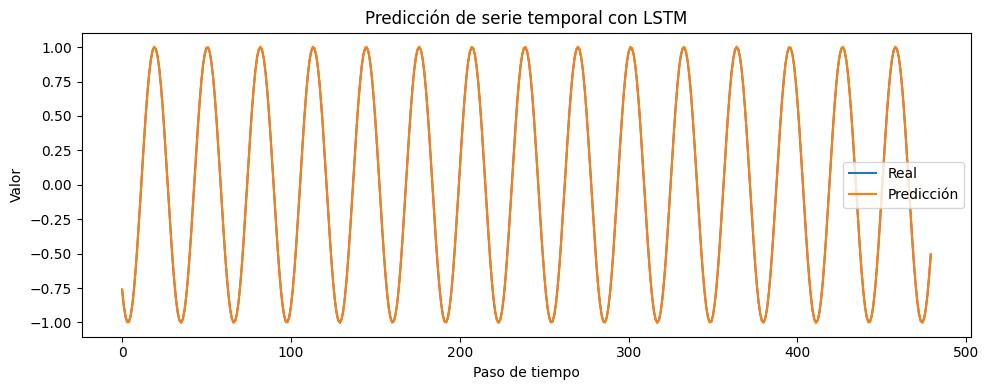

In [14]:
# Predecir con los mismos datos (ejemplo básico)
predicciones = model.predict(X)

# Invertir escalado
predicciones_inv = scaler.inverse_transform(predicciones)
y_real_inv = scaler.inverse_transform(y)

# Visualizar
plt.figure(figsize=(10,4))
plt.plot(y_real_inv, label='Real')
plt.plot(predicciones_inv, label='Predicción')
plt.title("Predicción de serie temporal con LSTM")
plt.xlabel("Paso de tiempo")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

### <span style="color:#00bfff">Ejemplo de predicción de datos de texto con LSTM</span>

1. Preparación del corpus del texto

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Texto base (puede ser más largo)
texto = """la inteligencia artificial transforma el mundo de la tecnología y la ciencia. 
        La IA está revolucionando industrias enteras, desde la medicina hasta el entretenimiento. 
        Con algoritmos avanzados y grandes volúmenes de datos, las máquinas están aprendiendo a 
        realizar tareas complejas que antes eran exclusivas de los humanos. Sin embargo, también 
        plantea desafíos éticos y sociales que deben ser abordados con responsabilidad y cuidado. 
        La IA no es solo una herramienta, sino un cambio de paradigma en nuestra forma de 
        interactuar con el mundo."""

# Crear vocabulario
caracteres = sorted(list(set(texto)))
char2idx = {c: i for i, c in enumerate(caracteres)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(caracteres)

# Convertir texto en secuencia de índices
secuencia = [char2idx[c] for c in texto]

# Crear pares entrada-salida
X = []
y = []
seq_length = 50

for i in range(len(secuencia) - seq_length):
    X.append(secuencia[i : i + seq_length])
    y.append(secuencia[i + seq_length])

X = np.array(X)
y = to_categorical(y, num_classes=vocab_size)

# Redimensionar para LSTM
X = X.reshape((X.shape[0], X.shape[1], 1)) / float(vocab_size)

2. Crear y entrenar el modelo LSTM

In [ ]:
model = Sequential([
    Input(shape=(seq_length, 1)),
    LSTM(256, return_sequences=True),
    LSTM(128),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam')
model.fit(X, y, batch_size=16, epochs=100, verbose=0)

3. Generar texto a partir de una semilla

In [17]:
# Elegir una semilla
semilla = "la inteligencia artificial transforma el mundo de "
entrada = [char2idx[c] for c in semilla]

# Generar caracteres
generado = semilla

for _ in range(60):
    sec = np.array(entrada[-seq_length:]).reshape(1, seq_length, 1) / float(vocab_size)
    pred = model.predict(sec, verbose=0)
    index = np.argmax(pred)
    generado += idx2char[index]
    entrada.append(index)

print("Texto generado:\n", generado) 

Texto generado:
 la inteligencia artificial transforma el mundo de la tecnología y la ciencia. 
        La IA notá revolucionan


> <span style="color:#ff7800;">_**Nota:**_</span> _El texto generado se ve gramaticalmente roto (p. ej. "notá revolucionan") — esto es **esperado**, no un error del código. El corpus de entrenamiento tiene apenas ~500 caracteres, mientras que el modelo (dos capas LSTM de 256 y 128 unidades) tiene muchísimos más parámetros que ejemplos de entrenamiento. Con tan poco texto, el modelo memoriza fragmentos del propio corpus en vez de aprender la estructura general del lenguaje (sobreajuste/_overfitting_). Para obtener texto más coherente haría falta un corpus bastante más grande (miles o millones de caracteres) o un modelo más pequeño relativo a los datos disponibles._

## <span style="color:#00bfff">Transformers</span>

Las RNN y LSTM vistas arriba procesan el texto **secuencialmente**, un token a la vez, lo que las hace lentas de entrenar (no se paralelizan bien) y les cuesta relacionar palabras muy alejadas entre sí en una oración larga (incluso las "puertas" del LSTM tienen límites prácticos).

Los **Transformers** (Vaswani et al., 2017, *"Attention is All You Need"*) resuelven esto con el mecanismo de **self-attention**: en vez de procesar la secuencia paso a paso, cada token puede "mirar" directamente a todos los demás tokens de la secuencia al mismo tiempo, calculando qué tan relevante es cada uno para interpretar el token actual. Esto permite:

- **Paralelización**: todos los tokens se procesan a la vez (no hace falta esperar al paso anterior), lo que acelera mucho el entrenamiento en GPU.
- **Dependencias de largo alcance**: una palabra al inicio de un párrafo puede influir directamente en una palabra al final, sin tener que "viajar" por cada paso intermedio como en una RNN.
- **Embeddings posicionales**: como el modelo ya no procesa la secuencia en orden, se le añade a cada token una codificación de su posición para que no pierda la noción de "quién va primero".

GPT-2 (que usaremos a continuación) es un Transformer *decoder-only*: apila muchos bloques de self-attention para predecir, dado el texto visto hasta el momento, cuál es el siguiente token más probable — y al repetir este proceso token por token, genera texto completo.

1. Instalación de HuggingFace Transformers

In [ ]:
%pip install transformers

2. Cargar GPT-2 de HuggingFace y generar texto. 

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# 1. Cargar el modelo preentrenado y el tokenizer
modelo = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# 2. Frase inicial
semilla = "Artificial intelligence will transform the world in the following ways:"

# 3. Codificar entrada
input_ids = tokenizer.encode(semilla, return_tensors="pt")

# 4. Generar texto
output = modelo.generate(
    input_ids,
    max_length=100,
    num_return_sequences=1,
    no_repeat_ngram_size=2,
    temperature=0.6,
    top_k=50,
    top_p=0.95,
    do_sample=True
)

# 5. Decodificar y mostrar resultado
texto_generado = tokenizer.decode(output[0], skip_special_tokens=True)
print("\nTexto generado:\n")
print(texto_generado)